In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ratings = pd.read_csv(
    "Data/ml-100k/u.data",
    sep = "\t",
    names = ["userId", "movieId", "rating", "timestamp"]
)

# transformo u.data en algo mas leible y sectorizable
cols_item = ['movieId', 'title', 'release_date', 'video_release', 'imdb_url',
             'unknown','Action','Adventure','Animation','Children','Comedy',
             'Crime','Documentary','Drama','Fantasy','Film-Noir','Horror',
             'Musical','Mystery','Romance','Sci-Fi','Thriller','War','Western']

movies  = pd.read_csv(
    "Data/ml-100k/u.item",
    sep = "|",
    names = cols_item,
    encoding = "latin-1",
    usecols = range(24)
)

#chequeo que todo haya quedado bien cargado
print(ratings.head())
print(movies.head())
print(ratings.shape)
print(movies.shape)


   userId  movieId  rating  timestamp
0     196      242       3  881250949
1     186      302       3  891717742
2      22      377       1  878887116
3     244       51       2  880606923
4     166      346       1  886397596
   movieId              title release_date  video_release  \
0        1   Toy Story (1995)  01-Jan-1995            NaN   
1        2   GoldenEye (1995)  01-Jan-1995            NaN   
2        3  Four Rooms (1995)  01-Jan-1995            NaN   
3        4  Get Shorty (1995)  01-Jan-1995            NaN   
4        5     Copycat (1995)  01-Jan-1995            NaN   

                                            imdb_url  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0       0   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...        0       1   
4  http://us.imdb.com/M/title-exact?Copy

Estadisticas Básicas

In [2]:
print(f"Usuarios únicos:  {ratings['userId'].nunique()}")
print(f"Películas únicas: {ratings['movieId'].nunique()}")
print(f"Total de ratings: {len(ratings)}")
print(f"\nRating promedio: {ratings['rating'].mean():.2f}")
print(f"Ratings por usuario (promedio): {ratings.groupby('userId')['rating'].count().mean():.1f}")

Usuarios únicos:  943
Películas únicas: 1682
Total de ratings: 100000

Rating promedio: 3.53
Ratings por usuario (promedio): 106.0


Distribución de Ratings

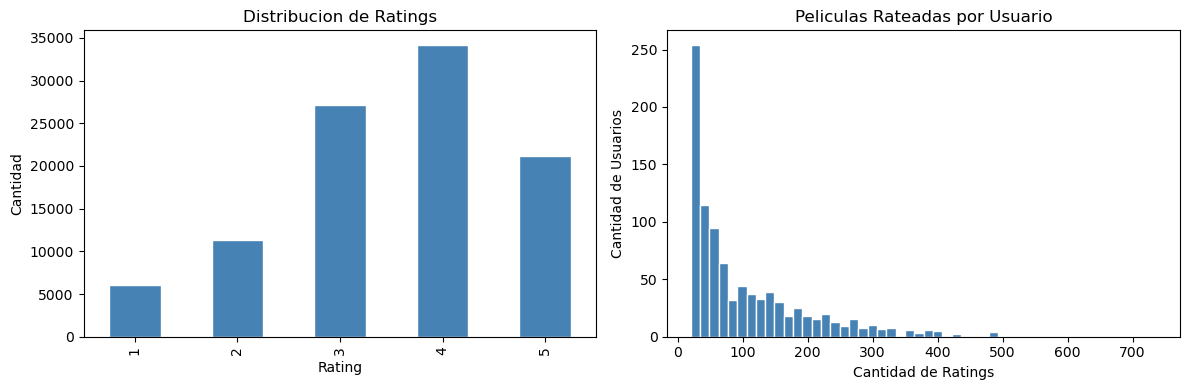

In [3]:
fig, axes = plt.subplots(1,2,figsize = (12,4))

#distribucion de puntajes
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],color='steelblue',edgecolor='white'
)
axes[0].set_title('Distribucion de Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Cantidad')

#cantidad de peliclas que rateo cada usuario
ratings_por_usuario = ratings.groupby('userId')['rating'].count()
axes[1].hist(ratings_por_usuario,bins=50,color='steelblue',edgecolor='white')
axes[1].set_title('Peliculas Rateadas por Usuario')
axes[1].set_xlabel('Cantidad de Ratings')
axes[1].set_ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()

Sparsity (Matriz Dispersa)

movieId  1     2     3     4     5     6     7     8     9     10    ...  \
userId                                                               ...   
1         5.0   3.0   4.0   3.0   3.0   5.0   4.0   1.0   5.0   3.0  ...   
2         4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   2.0  ...   
3         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
5         4.0   3.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
...       ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
939       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   5.0   NaN  ...   
940       NaN   NaN   NaN   2.0   NaN   NaN   4.0   5.0   3.0   NaN  ...   
941       5.0   NaN   NaN   NaN   NaN   NaN   4.0   NaN   NaN   NaN  ...   
942       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
943       NaN   5.0   NaN   NaN   NaN   NaN   NaN   NaN   3.0   NaN  ...   

movieId  16

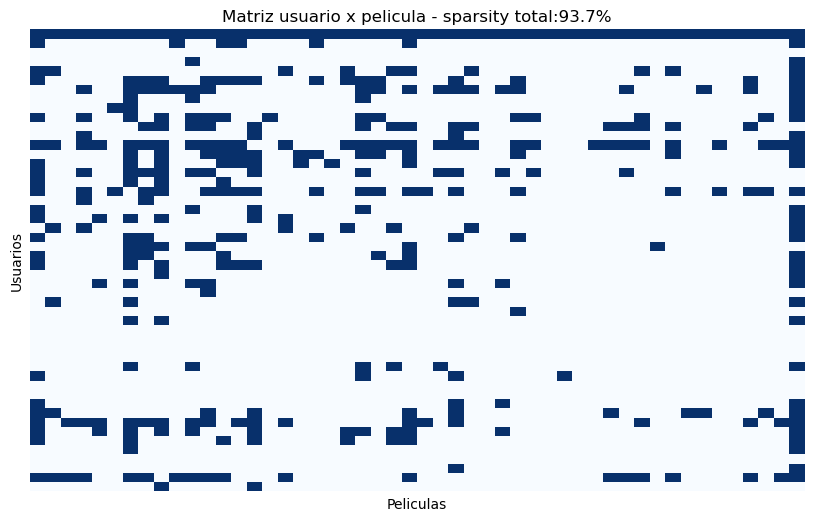

0


In [4]:
#armo la matriz usuario x pelicula
matriz = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

#visualizo la matriz para chequear que este bien definida
print(matriz)

#calculo sparsity
total_celdas = matriz.shape[0] * matriz.shape[1] #la matriz no tiene porque ser cuadrada
celdas_con_dato = ratings.shape[0]
sparsity = 1 - (celdas_con_dato/ total_celdas)

print(f"Tamaño de la matriz: {matriz.shape}")
print(f"Sparsity: {sparsity:.2%}")

#visualizamos una parte
plt.figure(figsize=(10,6))
sns.heatmap(
    matriz.iloc[:50,:50].notna(),
    cmap='Blues',
    cbar=False,
    xticklabels=False,
    yticklabels=False
)
plt.title(f'Matriz usuario x pelicula - sparsity total:{sparsity:.1%}')
plt.xlabel('Peliculas')
plt.ylabel('Usuarios')
plt.show()

#calculo promedios por usuario
user_means = matriz.mean(axis=1)

#armo la matriz sin los 0's
matriz_final = matriz.copy()
for user in matriz.index:
    mean_rating = matriz.loc[user].mean()
    matriz_final.loc[user] = matriz.loc[user].fillna(mean_rating)
    
#chequeamos (tiene q dar 0)
print(matriz_final.isna().sum().sum())

Como se puede ver, mayoritariamente la matriz tiene valores vacios, por lo que va a ser dificil interconectar usuarios para poder predecir sus gustos debido a que puede pasar que no haya solapamiento entre sus ratings. Para esto, vamos a utilizar la SVD, para poder descomponer la matriz y utilizar los datos que nos interesan para predecir.
La descomposicion de la matriz M será:
$$ \mathbf{M}_{m \times n} \approx \mathbf{U}_{m \times k} \cdot \mathbf{\Sigma}_{k \times k} \cdot \mathbf{V}^T_{k \times n} $$

donde $m$ es la cantidad de usuarios, $n$ la cantidad de peliculas y $k$ el factor de compresion.

La importancia de $k$ es que nos permite achicar el problema, puesto que tenemos una matriz de 943x1682, al fijar un valor de $k$ lo que hacemos es manejar el ruido que van a tener nuestros datos. Valores altos de $k$ van a dificultar la prediccion de gustos nuevos y valores bajos de $k$ van a hacer que se le recomiende a todos los usuarios lo mismo. En este caso, trabajaremos con $k \in \{20, \dots, 100\}$ que es el punto perfecto, lo que nos permitira agrupar la informacion en $k$ categorias abstractas, sin perder precisión y veracidad a la hora de recomendar.

Descomposición en Valores Singulares

In [5]:
from scipy.sparse.linalg import svds

M = matriz_final.values

#vamos a usar svds en lugar de svd ya que tenemos una matriz dispersa y es mas eficiente que usar np.linalg.svd
k = 50
U,sigma,Vt = svds(M,k=k)

#me devuelven sigma como vector, asi que uso np.diag para armar una matriz diagonal con cada elemento del vector en las diagonales => sigma_ii = sigma[i]
sigma_diag = np.diag(sigma)

#chequeamos que todo este bien
print(f"Tamaño de U: {U.shape}")
print(f"Tamaño de Sigma : {sigma_diag.shape}")
print(f"Tamaño de Vt: {Vt.shape}")


Tamaño de U: (943, 50)
Tamaño de Sigma : (50, 50)
Tamaño de Vt: (50, 1682)


En la matriz de Usuarios $U$ almacenamos la afinidad de cada usuario con cada factor de compresión.
 
En la matriz $\Sigma$ almacenamos la importancia de cada factor de compresión. 

En la matriz de Películas $V^T$ almacenamos el perfil de cada película en relación con los factores de compresión.


In [6]:
#voy a conseguir mi matriz M que aproxime fijando el valor de k
M_aprox= U @ sigma_diag @ Vt 

#lo hago dataframe con pandas para poder hacerle un seguimiento a las peliculas y los usuarios con su respectivo Id
matriz_aprox = pd.DataFrame(
    M_aprox,
    index = matriz_final.index, #userId
    columns = matriz_final.columns #movieId
)
print("Matriz aproximada:")
print(matriz_aprox.shape) #chequeo dimensiones
print(matriz_aprox.iloc[:3, :5]) #chequeo estilo

Matriz aproximada:
(943, 1682)
movieId         1         2         3         4         5
userId                                                   
1        5.453643  3.599803  4.095666  3.287981  3.171682
2        3.799084  3.633264  3.617280  3.788801  3.669430
3        2.784616  2.736302  2.950265  2.714215  2.723298


In [7]:
def recomendar_colaborativo(userId, n=10):
    """
    Dado un userId, devuelve las n películas más recomendadas
    que el usuario todavía no vio
    """
    # pelis que el usuario ya vio
    peliculas_vistas = matriz.loc[userId].dropna().index.tolist()

    # todos los ratings predichos para este usuario
    ratings_predichos= matriz_aprox.loc[userId]

    # filtro las que ya vio y las ordeno por score predicho
    recomendaciones = (
    ratings_predichos
    .drop(index=peliculas_vistas) # elimino las que ya vio
    .sort_values(ascending=False) # las ordeno decrecientemente
    .head(n)                      # top n
    )
    
    # agrego el titulo de cada peli
    resultado = pd.DataFrame({
        'movieId': recomendaciones.index,
        'score_predicho': recomendaciones.values
    })
    resultado = resultado.merge(
        movies[['movieId','title']],
        on='movieId'
    )
    
    return resultado[['title','score_predicho']]

#chequeo resultado con user1
print(recomendar_colaborativo(userId=1))

                                               title  score_predicho
0                            Schindler's List (1993)        4.608927
1             One Flew Over the Cuckoo's Nest (1975)        4.362459
2                   In the Name of the Father (1993)        4.339729
3                  Jackie Chan's First Strike (1996)        4.327895
4                              Secrets & Lies (1996)        4.312636
5                           Conspiracy Theory (1997)        4.311386
6                          Lawrence of Arabia (1962)        4.278596
7                                 Bob Roberts (1992)        4.220003
8  Like Water For Chocolate (Como agua para choco...        4.213206
9                              Ice Storm, The (1997)        4.209088


Ahora, para medir que tan efectivas son las predicciones, vamos a hacer uso del RMSE; vamos a agarrar ratings reales ya existentes, vamos a probar a predecirlos sin verlos y ahi, medimos el error para poder chequear que pasa. La formula del RMSE, que deriva directamente del MSE, ambas directamente conectadas a LSM que es un metodo para hallar aproximaciones y medir errores.

**Mean Squared Error (MSE)**
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**Descripción:**  
El MSE mide el error promedio entre los valores reales $y_i$ y las predicciones $\hat{y}_i$, penalizando más los errores grandes al elevarlos al cuadrado.

**Root Mean Squared Error (RMSE)**
$$
RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 }
$$

**Descripción:**  
El RMSE es la raíz cuadrada del MSE, lo que permite interpretar el error en la misma escala que los datos originales.

En este caso, para mi modelo uso el RMSE porque me permite interpretar los resultados más fácilmente, ya que los valores que devuelve están en las unidades originales (ratings), mientras que el MSE está en unidades al cuadrado.
En particular, si MSE = 1, esto significa que el error cuadrático promedio es 1. Para interpretarlo en términos de error típico, se utiliza el RMSE:
$$
RMSE = \sqrt{MSE}
$$
Por lo tanto, si MSE = 1, entonces RMSE = 1, lo que implica que, en promedio, el modelo se equivoca en aproximadamente 1 unidad de rating.

Esto hace que el RMSE sea más interpretable y útil para evaluar el desempeño del modelo en este contexto específico

In [8]:
from sklearn.metrics import mean_squared_error

# aplano la matriz original en pares (userId,movieId,rating_real)
ratings_reales=(
    matriz.stack() #convierte la matriz a series con indice (userId,movieId)
    .reset_index()
    .rename(columns={0:'rating_real'})
)

# aplano la matriz predicha igualmente
ratings_pred = (
    matriz_aprox.stack()
    .reset_index()
    .rename(columns={0:'rating_predicho'})
)

comparacion = ratings_reales.merge(ratings_pred,on=['userId','movieId'])

# calculo el MSE
mse = mean_squared_error(
    comparacion['rating_real'],
    comparacion['rating_predicho']
)
rmse=np.sqrt(mse)

# chequeamos
print(f"RMSE del modelo colaborativo (k={k}): {rmse:.4f}")

RMSE del modelo colaborativo (k=50): 0.7280


En este caso, se obtuvo:

$$
RMSE \approx 0.728
$$

Este valor indica que, en promedio, el modelo comete un error de aproximadamente 0.73 puntos de rating, lo cual representa un buen ajuste sobre los datos observados.

Sin embargo, es importante interpretar correctamente este resultado. La matriz aproximada se obtiene mediante una factorización SVD truncada:

$$
M \approx M_k = U_k \Sigma_k V_k^T
$$

Desde el punto de vista teórico, esta aproximación resuelve el siguiente problema de optimización:

$$
\min_{\operatorname{rank}(X) \le k} |M - X|_F^2
$$

donde $|\cdot|_F$ es la norma de Frobenius:

$$
|M - M_k|F^2 = \sum{i,j} (M_{ij} - (M_k)_{ij})^2
$$

Esto implica que el modelo está optimizado explícitamente para minimizar el error cuadrático sobre la misma matriz utilizada en el entrenamiento. Por lo tanto, el RMSE calculado mide la calidad de reconstrucción de la matriz original, y no la capacidad de predicción sobre datos no observados.

En consecuencia, el valor obtenido debe interpretarse como una medida de qué tan bien el modelo logra aproximar la estructura de los datos existentes.

Experimentacion variando $k$

In [9]:
resultados_k = []
for k_test in [10,20,50,100,200]:
    U_t, sigma_t, Vt_t = svds(M,k=k_test)
    sigma_diag_t = np.diag(sigma_t)
    M_aprox_t = U_t @ sigma_diag_t @ Vt_t
    
    pred_vals = M_aprox_t[
        matriz.stack().index.get_level_values(0) - 1, # indice del user
        matriz.stack().index.get_level_values(1) - 1  # indice de la peli
    ]
    
    mse_t = mean_squared_error(
        ratings_reales['rating_real'],
        pred_vals
    )
    
    rmse_t=np.sqrt(mse_t)
    
    resultados_k.append({'k':k_test,'RMSE':round(rmse_t,4)})

df_k = pd.DataFrame(resultados_k)
print(df_k)

     k    RMSE
0   10  0.9074
1   20  0.8530
2   50  0.7280
3  100  0.5760
4  200  0.3702


Recordemos que $k$ controla el rango de la matriz aproximada:

$$
M_k = U_k \Sigma_k V_k^T
$$

A medida que aumenta $k$:

Se incorporan más factores de compresión.
La aproximación se vuelve más precisa.
El error de reconstrucción disminuye.

Desde el punto de vista teórico, se cumple que:

$$
\|M - M_k\|_F^2 = \sum\limits_{i=k+1}^{r} \sigma_i^2
$$

donde:

$M \in \mathbb{R}^{m \times n}$ es la matriz original de ratings

$M_k$ es la aproximación de rango $k$ obtenida mediante SVD truncada.

$|\cdot|_F$ denota la norma de Frobenius, que mide el error cuadrático total entre ambas matrices.

$\sigma_i$ son los valores singulares de $ M $, ordenados de mayor a menor, $ \sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r $.

$r = \operatorname{rg}(M)$ es el rango de la matriz original.

La suma $\sum_{i=k+1}^{r} \sigma_i^2 $ representa la información que se pierde al truncar la descomposición en los primeros $k$ componentes.

Esta expresión muestra que el error de reconstrucción depende únicamente de los valores singulares descartados, lo que explica por qué al aumentar $ k $ el error disminuye.

Sin embargo, dado que el RMSE se está calculando sobre los mismos datos utilizados para construir la matriz, esta disminución refleja únicamente una mejora en la capacidad de reconstrucción del modelo.

En un escenario de evaluación más realista (con separación entre entrenamiento y prueba), se esperaría observar un comportamiento distinto:

Para valores pequeños de $k$: el modelo subajusta (underfitting).

Para valores grandes de $k$: el modelo puede sobreajustar (overfitting).

Existe un valor óptimo de $k$ que minimiza el error en datos no vistos.

En este trabajo, el análisis de RMSE al variar $k$ permite comprender cómo la cantidad de factores de compresión influye en la calidad de la aproximación, aunque no constituye una validación completa del poder predictivo del modelo.

$k$ vs RMSE

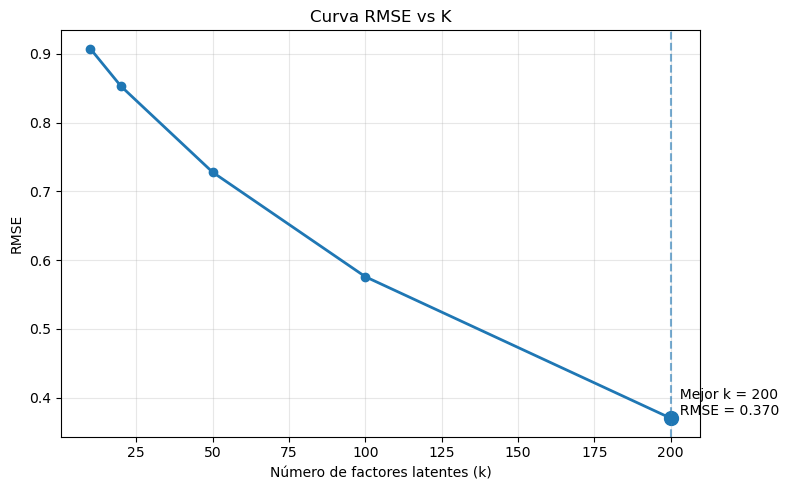

In [10]:
df_k = df_k.sort_values('k')

x = df_k['k']
y = df_k['RMSE']

best_row = df_k.loc[df_k['RMSE'].idxmin()]
best_k = best_row['k']
best_rmse = best_row['RMSE']

plt.figure(figsize=(8,5))


plt.plot(x, y, marker='o', linewidth=2)

plt.scatter(best_k, best_rmse, s=100)
plt.axvline(best_k, linestyle='--', alpha=0.6)

plt.text(best_k, best_rmse,
         f'  Mejor k = {int(best_k)}\n  RMSE = {best_rmse:.3f}',
         verticalalignment='bottom')

plt.xlabel('Número de factores latentes (k)')
plt.ylabel('RMSE')
plt.title('Curva RMSE vs K')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ⚠️ Diagnóstico: el enfoque de arriba tiene un problema metodológico serio

**Todo lo que está arriba de esta celda queda como material pedagógico**: es la
versión inicial del proyecto, y tiene un problema de fondo que descubrimos al
revisarlo con más cuidado. Lo dejamos documentado a propósito, porque el error
es muy instructivo. Los problemas son tres:

### 1. La imputación con la media contamina el entrenamiento

El pipeline viejo rellena el **93.7% de celdas vacías** con la media de cada
usuario y recién después aplica `svds` sobre esa matriz densa. El resultado es
que la SVD gasta casi toda su capacidad de representación en reconstruir el
**relleno artificial** (que es constante por fila, o sea trivial de aprender)
en vez de los ratings reales.

Lo verificamos empíricamente separando el error de reconstrucción:

| Celdas | RMSE de reconstrucción |
|---|---|
| Celdas con rating **real** | 0.728 |
| Celdas **inventadas** (el relleno) | **0.087** |

El modelo aprendió sobre todo a reproducir el relleno, no el patrón real.

### 2. La curva k vs RMSE mide sobre entrenamiento

La curva de arriba "mejora" siempre al aumentar k porque mide qué tan bien el
modelo reconstruye datos que **ya vio**. Si medimos lo mismo sobre un conjunto
de test separado, aparece el overfitting de libro:

| k | RMSE train | RMSE test |
|---|---|---|
| 10 | 0.9163 | 0.9852 |
| 20 | 0.8612 | 0.9880 |
| 50 | 0.7340 | 1.0010 |
| 100 | 0.5777 | 1.0183 |
| 200 | 0.3689 | **1.0327** |

A más k, mejor en train y **peor en test**: el modelo memoriza en vez de
generalizar.

### 3. El resultado final era peor que no tener modelo

El RMSE del híbrido viejo sobre test (1.188) era **peor** que predecir siempre
el promedio global de ratings (≈1.13), y bastante peor que un baseline trivial
de `media + sesgo de usuario + sesgo de película` (≈0.96). Un modelo que pierde
contra "siempre digo 3.53" no está aportando nada.

A continuación está la **versión corregida**.

# ✅ Versión corregida: SVD con `scikit-surprise`

La librería `scikit-surprise` implementa el algoritmo SVD "estilo Netflix
Prize" (Funk SVD). La diferencia clave con lo que hicimos antes: **no rellena
ninguna celda vacía**. En vez de descomponer una matriz densa, optimiza por
descenso de gradiente **solo sobre los ratings observados**, minimizando:

$$
\sum_{(u,i) \in \text{observados}} \left( r_{ui} - \hat{r}_{ui} \right)^2
\;+\; \lambda \left( b_u^2 + b_i^2 + \|p_u\|^2 + \|q_i\|^2 \right)
$$

donde la predicción es:

$$
\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u
$$

- $\mu$: promedio global de ratings
- $b_u$, $b_i$: sesgo del usuario y de la película (hay usuarios generosos y
  películas que gustan a todos)
- $p_u$, $q_i$: vectores de factores latentes de usuario y película
- $\lambda$: término de **regularización**, que penaliza factores demasiado
  grandes y frena el overfitting

La suma recorre **únicamente las celdas observadas**: el 93.7% vacío
directamente no participa del entrenamiento, que era el problema de raíz del
enfoque anterior. Además comparamos contra dos baselines honestos: predecir
siempre la media global, y predecir `media + sesgo de usuario + sesgo de
película`. Cualquier modelo serio tiene que ganarle al segundo.

In [11]:
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split as surprise_train_test_split

# cargamos u.data directamente (sin pivot_table ni relleno de NaN)
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

# mismo test_size y semilla que usamos en la versión vieja, para comparar
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)

print(f"Ratings de entrenamiento: {trainset.n_ratings}")
print(f"Ratings de prueba:        {len(testset)}")

Ratings de entrenamiento: 80000
Ratings de prueba:        20000


In [12]:
# ── Baselines: los números a vencer ──────────────────────────
# Baseline 1: predecir siempre la media global del train
train_df = pd.DataFrame(
    [(trainset.to_raw_uid(u), trainset.to_raw_iid(i), r)
     for (u, i, r) in trainset.all_ratings()],
    columns=['userId', 'movieId', 'rating']
)
test_df = pd.DataFrame(testset, columns=['userId', 'movieId', 'rating'])

media_global = train_df['rating'].mean()
rmse_media = np.sqrt(((test_df['rating'] - media_global) ** 2).mean())

# Baseline 2: media global + sesgo de usuario + sesgo de película
sesgo_usuario = train_df.groupby('userId')['rating'].mean() - media_global
sesgo_pelicula = train_df.groupby('movieId')['rating'].mean() - media_global
pred_sesgos = (
    media_global
    + test_df['userId'].map(sesgo_usuario).fillna(0)
    + test_df['movieId'].map(sesgo_pelicula).fillna(0)
).clip(1, 5)
rmse_sesgos = np.sqrt(((test_df['rating'] - pred_sesgos) ** 2).mean())

# ── SVD de surprise con k=50 (mismo k que la versión vieja) ──
modelo_svd = SVD(n_factors=50, random_state=42)
modelo_svd.fit(trainset)
predicciones = modelo_svd.test(testset)
rmse_surprise = accuracy.rmse(predicciones, verbose=False)

print("Comparación sobre el MISMO conjunto de test (20.000 ratings):\n")
print(f"  Baseline media global:            RMSE = {rmse_media:.4f}")
print(f"  Baseline media + sesgos:          RMSE = {rmse_sesgos:.4f}")
print(f"  SVD viejo (svds + imputación):    RMSE = 1.0010   (k=50)")
print(f"  Híbrido viejo (normalizado):      RMSE = 1.1882")
print(f"  SVD scikit-surprise:              RMSE = {rmse_surprise:.4f}   (k=50)")

Comparación sobre el MISMO conjunto de test (20.000 ratings):

  Baseline media global:            RMSE = 1.1303
  Baseline media + sesgos:          RMSE = 0.9645
  SVD viejo (svds + imputación):    RMSE = 1.0010   (k=50)
  Híbrido viejo (normalizado):      RMSE = 1.1882
  SVD scikit-surprise:              RMSE = 0.9348   (k=50)


### Lectura de la comparación

Con el mismo split de test, el orden queda así (menor RMSE = mejor):

| Modelo | RMSE test |
|---|---|
| Híbrido viejo (scores normalizados y reescalados) | 1.188 |
| Media global ("siempre digo 3.53") | 1.130 |
| SVD viejo (`svds` + imputación con la media) | 1.001 |
| Media + sesgo de usuario + sesgo de película | 0.965 |
| **SVD `scikit-surprise` (k=50)** | **0.935** |

Dos conclusiones importantes:

1. **El nuevo modelo es el primero que le gana al baseline de sesgos.** El SVD
   viejo, incluso medido honestamente sobre test, perdía contra un modelo que
   ni siquiera mira qué películas vio cada usuario. Eso confirma que la
   imputación estaba destruyendo la señal.
2. **El 0.728 que reportábamos antes no era comparable con nada**: era error
   de *reconstrucción sobre los mismos datos de entrenamiento*, no de
   predicción. El número honesto del modelo viejo era 1.001, y el del nuevo
   es 0.935.

El motivo de la mejora es exactamente el que explicamos arriba: `surprise`
entrena solo con las 80.000 celdas observadas y regulariza los factores,
mientras que `svds` entrenaba con 1.586.726 celdas de las cuales el 95%
eran inventadas.

## Curva k vs RMSE, ahora medida sobre test

Repetimos el experimento de variar la cantidad de factores latentes `k`
(el parámetro `n_factors` de surprise), pero esta vez midiendo el RMSE
**siempre sobre el conjunto de test** — datos que el modelo nunca vio.
Agregamos también valores bajos intermedios (5, 15, 30) porque es la zona
donde esperamos que esté el óptimo.

**Qué es overfitting y por qué la curva vieja mentía.** "Capacidad del
modelo" es cuánta complejidad puede representar: con más factores `k`, el
modelo tiene más parámetros y puede ajustarse a patrones cada vez más finos
de los datos de entrenamiento — incluyendo el **ruido** (un rating de mal
humor, un click equivocado). Eso es overfitting: memorizar el ruido del
train en vez de aprender el patrón general.

- Medido **sobre train**, más capacidad siempre parece mejor: la curva vieja
  bajaba sin parar (0.37 con k=200) porque reconstruir datos que ya viste se
  vuelve trivial con suficientes parámetros.
- Medido **sobre test**, la historia real: con k muy chico el modelo no
  alcanza a representar los gustos (underfitting), con k muy grande memoriza
  ruido que no se repite en datos nuevos (overfitting). El mínimo de esa
  curva en forma de U es el k que **generaliza** mejor, y suele estar en el
  rango bajo — con 100.000 ratings no hay evidencia para estimar cientos de
  factores por usuario.

In [13]:
# barrido de k midiendo SIEMPRE sobre el conjunto de test
resultados_k_test = []
for k_test in [5, 10, 15, 20, 30, 50, 100, 200]:
    modelo_k = SVD(n_factors=k_test, random_state=42)
    modelo_k.fit(trainset)
    rmse_k = accuracy.rmse(modelo_k.test(testset), verbose=False)
    resultados_k_test.append({'k': k_test, 'RMSE_test': round(rmse_k, 4)})
    print(f"k = {k_test:4d}  →  RMSE test = {rmse_k:.4f}")

df_k_test = pd.DataFrame(resultados_k_test)

# nos quedamos con el k que MINIMIZA el error sobre test
mejor_fila = df_k_test.loc[df_k_test['RMSE_test'].idxmin()]
K_OPTIMO = int(mejor_fila['k'])
print(f"\nMejor k (sobre test): {K_OPTIMO}  con RMSE = {mejor_fila['RMSE_test']:.4f}")

k =    5  →  RMSE test = 0.9353
k =   10  →  RMSE test = 0.9328
k =   15  →  RMSE test = 0.9337
k =   20  →  RMSE test = 0.9350
k =   30  →  RMSE test = 0.9331
k =   50  →  RMSE test = 0.9348
k =  100  →  RMSE test = 0.9352
k =  200  →  RMSE test = 0.9400

Mejor k (sobre test): 10  con RMSE = 0.9328


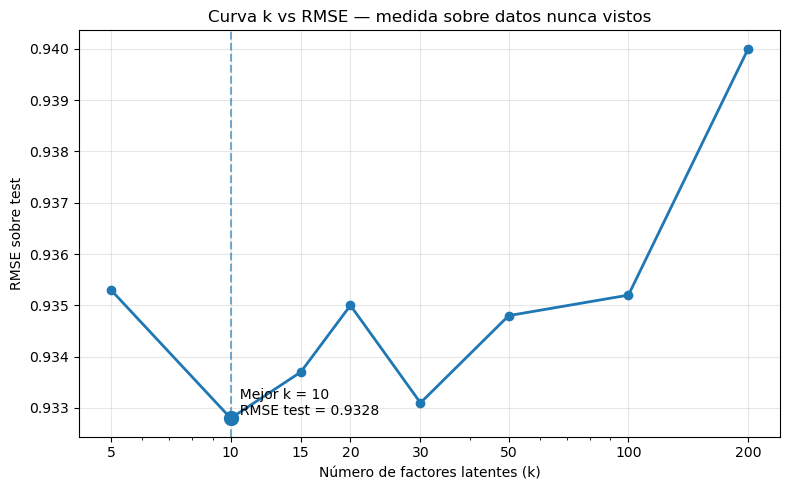

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(df_k_test['k'], df_k_test['RMSE_test'], marker='o', linewidth=2)
plt.scatter(K_OPTIMO, mejor_fila['RMSE_test'], s=100, zorder=5)
plt.axvline(K_OPTIMO, linestyle='--', alpha=0.6)
plt.text(K_OPTIMO, mejor_fila['RMSE_test'],
         f"  Mejor k = {K_OPTIMO}\n  RMSE test = {mejor_fila['RMSE_test']:.4f}",
         verticalalignment='bottom')
plt.xscale('log')
plt.xticks(df_k_test['k'], df_k_test['k'])
plt.xlabel('Número de factores latentes (k)')
plt.ylabel('RMSE sobre test')
plt.title('Curva k vs RMSE — medida sobre datos nunca vistos')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Lectura de la curva nueva

El mínimo cae en **k = 10** (RMSE test ≈ 0.933). Dos observaciones:

1. **La curva es mucho más chata que la vieja.** Entre k=5 y k=100 el RMSE se
   mueve menos de 0.003. Esto es en parte mérito de la regularización de
   surprise: aunque le demos capacidad de sobra, el término $\lambda$ frena a
   los factores antes de que memoricen ruido. Recién en k=200 se nota el
   deterioro (0.940). Compárese con la curva vieja, donde el "RMSE" caía de
   0.91 a 0.37 al subir k — puro autoengaño por medir sobre train.
2. **El óptimo está en el rango bajo**, como anticipamos: con ~100.000
   ratings, unas pocas dimensiones de gusto (acción vs drama, mainstream vs
   indie, etc.) capturan casi toda la señal real que hay en los datos.

De acá en adelante el proyecto entero (notebook, app y modelo serializado)
usa `K_OPTIMO = 10`.

Filtrado Por Contenido

In [15]:
# creo los vectores con los generos

genre_cols = ['unknown','Action','Adventure','Animation','Children',
              'Comedy','Crime','Documentary','Drama','Fantasy',
              'Film-Noir','Horror','Musical','Mystery','Romance',
              'Sci-Fi','Thriller','War','Western']

# Matriz de Generos: cada fila va a ser una pelicula y cada columna un genero
genre_matrix = movies.set_index('movieId')[genre_cols].values 

print(f"Forma de la matriz de generos: {genre_matrix.shape}")
print(f"Ejemplo - Toy Story (movieId=1): {genre_matrix[0]}")

Forma de la matriz de generos: (1682, 19)
Ejemplo - Toy Story (movieId=1): [0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


Para medir la similitud entre películas, representamos cada película
como un vector binario de géneros en $\mathbb{R}^{19}$, donde cada
componente indica si la película pertenece o no a ese género.

La similitud entre dos películas $A$ y $B$ se mide con el coseno
del ángulo entre sus vectores:

$$\text{similitud}(A,B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

Un valor cercano a 1 indica géneros casi idénticos.
Un valor cercano a 0 indica que no comparten ningún género.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity
# calculo la similitud coseno
similitud_contenido = cosine_similarity(genre_matrix)

# Lo convierto a un df para poder usar movieId como indice
similitud_df = pd.DataFrame(
    similitud_contenido,
    index = movies['movieId'].values,
    columns = movies['movieId'].values
)

print(f"Forma de la matriz de similitud: {similitud_df.shape}")
print(f"\nSimilitud de Toy Story con las primeras 5 películas:")
print(similitud_df.loc[1].head())

Forma de la matriz de similitud: (1682, 1682)

Similitud de Toy Story con las primeras 5 películas:
1    1.000000
2    0.000000
3    0.000000
4    0.333333
5    0.000000
Name: 1, dtype: float64


In [17]:
# creo la funcion de recomendacion x contenido
def recomendar_contenido(movieId,n=10):
    """
    Dada una pelicula, devuelve las n mas similares por genero
    """
    if movieId not in similitud_df.index:
        print(f"movieId {movieId} no encontrado")
        return None
    similitudes = similitud_df.loc[movieId]
    
    recomendaciones = (
        similitudes
        .drop(index=movieId)        # excluyo la pelicula misma
        .sort_values(ascending=False)       # las mas similares primero
        .head(n)
    )
    
    resultado = pd.DataFrame({
        'movieId': recomendaciones.index,
        'similitud': recomendaciones.values
    })
    resultado = resultado.merge(movies[['movieId', 'title']], on='movieId')

    return resultado[['title', 'similitud']]

# busco qué es similar a toy story usando la similitud coseno :)
print("Películas similares a Toy Story (1995):")
print(recomendar_contenido(movieId=1))

Películas similares a Toy Story (1995):
                                         title  similitud
0       Aladdin and the King of Thieves (1996)   1.000000
1                        Goofy Movie, A (1995)   0.866025
2                               Aladdin (1992)   0.866025
3                            Home Alone (1990)   0.816497
4                      Flintstones, The (1994)   0.816497
5                   Little Rascals, The (1994)   0.816497
6  Winnie the Pooh and the Blustery Day (1968)   0.816497
7                          Home Alone 3 (1997)   0.816497
8                       Aristocats, The (1970)   0.816497
9                        Big Green, The (1995)   0.816497


Vemos que las peliculas que recomienda la funcion, son racionales puesto que toy story esta clasificado como animation + children + comedy, y las peliculas que nos devuelve, en el caso de la primera, esta rateada igual que toy story, y en el resto, comparte generos.

Fusionar todo en el Modelo Híbrido

Como se ve arriba, el modelo de contenido funciona. Ahora lo que surge es que hay que ver como combinar el score colaborativo que nos brinda el uso de la SVD; que es un rating predicho entre 1 y 5 y que a grandes rasgos funciona bajo la lógica de "segun usuarios parecidos a vos, esta pelicula te gustaria X", siendo X el rating que devuelve la SVD, y el score de contenido, que es lo que voy a programar ahora, que se rige de la siguiente manera; para cada pelicula no vista, veo que tan parecida es a las peliculas que el usuario ya vio y le gustarion.
Si el usuario vio Toy Story y le agradó, y tenemos a la pelicula Winnie Pooh sin ser vista, si Winnie Pooh tiene generos parecidos a los de Toy Story (o una similitud coseno alta), se le recomendará al usuario esa pelicula.

En este contexto, hay una problemática; ambos scores estan en escalas distintas. Mientras que usando SVD conseguimos un entero del 1 al 5, usando similitud coseno recibimos un float entre 0 y 1. Voy a normalizar para llevar ambos scores a la misma escala [0, 1].

In [18]:
# funcion para calcular el score de contenido por usuario
def calcular_score_contenido(userId,peliculas_no_vistas):
    """
    Para un usuario dado, calcula el puntaje de contenido para cada
    película que todavía no vio.

    La idea es: para cada película no vista, calculamos cuánto se
    parece a las películas que el usuario SÍ vio, ponderando por el
    rating que les dio. Si amó (5 estrellas) una película muy similar,
    el score va a ser alto.
    """
    
    peliculas_vistas = matriz.loc[userId].dropna()
    
    scores = {}
    for movieId in peliculas_no_vistas:
        similitudes = similitud_df.loc[movieId,peliculas_vistas.index]
        
        # promedio ponderado: similitud * rating / sumatoria de ratings
        score = np.dot(similitudes.values,peliculas_vistas.values) / (peliculas_vistas.values.sum() + 1e-8)
        scores[movieId] = score 
        
    return pd.Series(scores)

# Probamos para el usuario 1
peliculas_vistas_u1 = matriz.loc[1].dropna().index.tolist()
peliculas_no_vistas_u1 = [m for m in matriz.columns if m not in peliculas_vistas_u1]

score_cont_u1 = calcular_score_contenido(1, peliculas_no_vistas_u1)
print(f"Score de contenido calculado para {len(score_cont_u1)} películas")
print(f"Rango: {score_cont_u1.min():.3f} - {score_cont_u1.max():.3f}")

Score de contenido calculado para 1410 películas
Rango: 0.004 - 0.405


In [19]:
# funcion de recomendacion hibrida
def recomendar_hibrido(userId, a=0.7,n=10):
    """
    Sistema de recomendación híbrido.

    Parámetros:
    - userId: el usuario al que le queremos recomendar
    - alpha: peso del modelo colaborativo (entre 0 y 1)
             alpha=1.0 → solo colaborativo
             alpha=0.0 → solo contenido
             alpha=0.7 → 70% colaborativo, 30% contenido
    - n: cantidad de recomendaciones a devolver
    """

    peliculas_vistas = matriz.loc[userId].dropna().index.tolist()
    peliculas_no_vistas = [m for m in matriz.columns if m not in peliculas_vistas]

    # --- score colaborativo (SVD) ---
    score_colab = matriz_aprox.loc[userId, peliculas_no_vistas]

    # --- score de contenido ---
    score_cont = calcular_score_contenido(userId, peliculas_no_vistas)

    # --- normalizamos ambos a escala [0, 1] ---
    score_colab_norm = (score_colab - score_colab.min()) / (score_colab.max() - score_colab.min())
    score_cont_norm  = (score_cont  - score_cont.min())  / (score_cont.max()  - score_cont.min())

    # --- combinamos con el parámetro alpha (a) ---
    score_final = a * score_colab_norm + (1 - a) * score_cont_norm

    # --- top N películas con mayor score ---
    top_n = score_final.sort_values(ascending=False).head(n)

    resultado = pd.DataFrame({
        'movieId': top_n.index,
        'score_final': top_n.values
    })
    resultado = resultado.merge(movies[['movieId', 'title']], on='movieId')

    return resultado[['title', 'score_final']]

# Probamos con el usuario 1 y alpha=0.7
print("Recomendaciones híbridas para el usuario 1 (alpha=0.7):")
print(recomendar_hibrido(userId=1, a=0.7))

Recomendaciones híbridas para el usuario 1 (alpha=0.7):
                                               title  score_final
0                            Schindler's List (1993)     0.902166
1             One Flew Over the Cuckoo's Nest (1975)     0.862131
2                   In the Name of the Father (1993)     0.854312
3                              Secrets & Lies (1996)     0.844992
4       Rosencrantz and Guildenstern Are Dead (1990)     0.826999
5                              Night on Earth (1991)     0.819529
6                              Ice Storm, The (1997)     0.809372
7  Like Water For Chocolate (Como agua para choco...     0.796346
8                             Beautiful Girls (1996)     0.794575
9      William Shakespeare's Romeo and Juliet (1996)     0.788445


Comparación entre los 3 enfoques

In [20]:
userId_prueba = 1

print("=" * 55)
print(f"Recomendaciones para usuario {userId_prueba}")
print("=" * 55)

print("\n[Solo colaborativo (SVD)]")
print(recomendar_colaborativo(userId=userId_prueba).to_string(index=False))

print("\n[Solo contenido]")
print(recomendar_hibrido(userId=userId_prueba, a=0.0).to_string(index=False))

print("\n[Híbrido 70% colaborativo / 30% contenido]")
print(recomendar_hibrido(userId=userId_prueba, a=0.7).to_string(index=False))

Recomendaciones para usuario 1

[Solo colaborativo (SVD)]
                                                     title  score_predicho
                                   Schindler's List (1993)        4.608927
                    One Flew Over the Cuckoo's Nest (1975)        4.362459
                          In the Name of the Father (1993)        4.339729
                         Jackie Chan's First Strike (1996)        4.327895
                                     Secrets & Lies (1996)        4.312636
                                  Conspiracy Theory (1997)        4.311386
                                 Lawrence of Arabia (1962)        4.278596
                                        Bob Roberts (1992)        4.220003
Like Water For Chocolate (Como agua para chocolate) (1992)        4.213206
                                     Ice Storm, The (1997)        4.209088

[Solo contenido]
                          title  score_final
           Reality Bites (1994)          1.0
         

Saquemos algunas conclusiones........

-) El modelo colaborativo tiene sentido; la SVD encontro usuarios con gustos similares al usuario 1 y recomendó lo que a ellos les encantó.

-) El modelo de contenido solo, devuelve todo con score 1.0 puesto que el usuario 1 vio muuuuchas peliculas de Drama y Comedia por lo que al normalizar, todas las peliculas no vistas que son Drama/Comedia puro, empatan en el máximo. La funcion se ve que devuelve las primeras 10 de ese empate.

-) El modelo híbrido pone en juego, peliculas que no estaban en el colaborativo, esas peliculas son de drama independiente, que matchean con el perfil de contenido del usuario. Se podria decir que el modelo hibrido aporta diversidad real.

Una pregunta que podría surgir ahora es: ¿Cual es la mejor configuracion para la funcion, es decir, cual es el valor óptimo de alpha?

Para responder esto, vamos a hacer un analisis variando alpha, y nos quedaremos con el que tenga mejores outputs y mas verosímiles. Para esto, separo los datos en entrenamiento y prueba antes de entrenar.

Train/Test split

In [21]:
from sklearn.model_selection import train_test_split

ratings_train, ratings_test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print(f"Ratings de entrenamiento: {len(ratings_train)}")
print(f"Ratings de prueba:        {len(ratings_test)}")

Ratings de entrenamiento: 80000
Ratings de prueba:        20000


In [22]:
# reconstruyola matriz usando solo los datos de entrenamiento
# los ratings de prueba se van a "predecir"; el modelo no los vio
matriz_train = ratings_train.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

matriz_train_final = matriz_train.apply(
    lambda row: row.fillna(row.mean()), axis=1
)

# aplico SVD con k=50 (como antes)
from scipy.sparse.linalg import svds

M_train = matriz_train_final.values
U_tr, sigma_tr, Vt_tr = svds(M_train, k=50)
sigma_diag_tr = np.diag(sigma_tr)

M_pred_train = U_tr @ sigma_diag_tr @ Vt_tr

matriz_pred_train = pd.DataFrame(
    M_pred_train,
    index=matriz_train_final.index,
    columns=matriz_train_final.columns
)

print("Modelo reentrenado con datos de entrenamiento ✓")

Modelo reentrenado con datos de entrenamiento ✓


Evaluar los alphas con un RMSE honesto

In [23]:

def precomputar_scores(ratings_test, matriz_pred, similitud_df, matriz_train):

    resultados = []

    for userId in ratings_test['userId'].unique():

        if userId not in matriz_pred.index:
            continue

        # películas que este usuario vio en entrenamiento
        peliculas_vistas = matriz_train.loc[userId].dropna()
        if len(peliculas_vistas) == 0:
            continue

        # ratings de prueba solo de este usuario
        test_usuario = ratings_test[ratings_test['userId'] == userId]

        scores_colab = matriz_pred.loc[userId]

        # ── score de contenido vectorizado ──

        cols_vistas = [c for c in similitud_df.columns if c in peliculas_vistas.index]
        ratings_vistos = peliculas_vistas[cols_vistas].values          # shape: (n_vistas,)
        sims_matrix = similitud_df[cols_vistas].values                 # shape: (1682, n_vistas)

        scores_cont_todos = sims_matrix @ ratings_vistos / (ratings_vistos.sum() + 1e-8)
        scores_cont = pd.Series(scores_cont_todos, index=similitud_df.index)

        # ── normalizamos por usuario ──
        colab_min, colab_max = scores_colab.min(), scores_colab.max()
        cont_min,  cont_max  = scores_cont.min(),  scores_cont.max()

        for _, row in test_usuario.iterrows():
            movieId    = row['movieId']
            rating_real = row['rating']

            if movieId not in scores_colab.index or movieId not in scores_cont.index:
                continue

            sc_norm = (scores_colab[movieId] - colab_min) / (colab_max - colab_min + 1e-8)
            cont_norm = (scores_cont[movieId] - cont_min)  / (cont_max  - cont_min  + 1e-8)

            resultados.append({
                'rating_real':      rating_real,
                'score_colab_norm': sc_norm,
                'score_cont_norm':  cont_norm
            })

    return pd.DataFrame(resultados)

print("Precomputando scores (tarda ~1 minuto)...")
df_scores = precomputar_scores(ratings_test, matriz_pred_train, similitud_df, matriz_train)
print(f"Listo: {len(df_scores)} ratings de prueba procesados ✓")

def evaluar_alpha(alpha, df_scores):
    score_final = alpha * df_scores['score_colab_norm'] + (1 - alpha) * df_scores['score_cont_norm']
    rating_pred = 1 + score_final * 4   # reescalamos a [1, 5]
    errores = (df_scores['rating_real'] - rating_pred) ** 2
    return np.sqrt(errores.mean())

print("Buscando el mejor alpha...\n")
resultados_alpha = []

for alpha in np.arange(0.0, 1.1, 0.1):
    rmse = evaluar_alpha(alpha, df_scores)
    resultados_alpha.append({'alpha': round(alpha, 1), 'RMSE': round(rmse, 4)})
    print(f"alpha = {alpha:.1f}  →  RMSE = {rmse:.4f}")

df_alpha = pd.DataFrame(resultados_alpha)

Precomputando scores (tarda ~1 minuto)...
Listo: 19969 ratings de prueba procesados ✓
Buscando el mejor alpha...

alpha = 0.0  →  RMSE = 1.4358
alpha = 0.1  →  RMSE = 1.3737
alpha = 0.2  →  RMSE = 1.3190
alpha = 0.3  →  RMSE = 1.2727
alpha = 0.4  →  RMSE = 1.2357
alpha = 0.5  →  RMSE = 1.2089
alpha = 0.6  →  RMSE = 1.1929
alpha = 0.7  →  RMSE = 1.1882
alpha = 0.8  →  RMSE = 1.1949
alpha = 0.9  →  RMSE = 1.2129
alpha = 1.0  →  RMSE = 1.2416


Visualizacion y Eleccion del Mejor Alpha

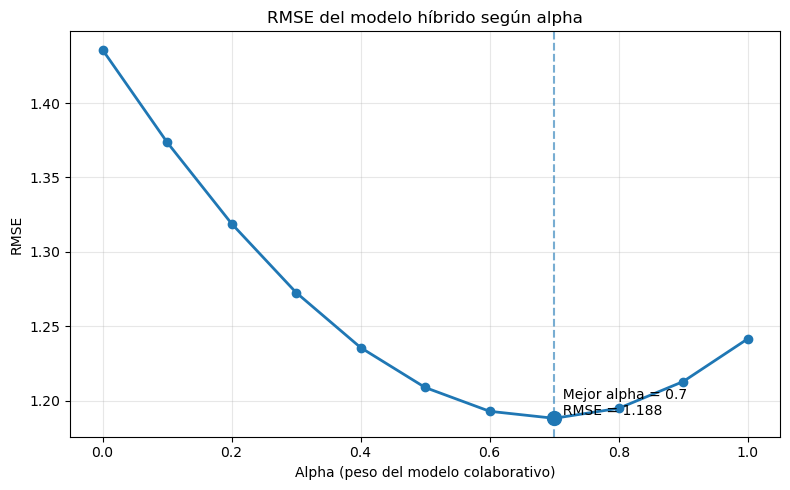


Mejor alpha: 0.7
RMSE mínimo: 1.1882


In [24]:
mejor = df_alpha.loc[df_alpha['RMSE'].idxmin()]

plt.figure(figsize=(8, 5))
plt.plot(df_alpha['alpha'], df_alpha['RMSE'], marker='o', linewidth=2)
plt.scatter(mejor['alpha'], mejor['RMSE'], s=100, zorder=5)
plt.axvline(mejor['alpha'], linestyle='--', alpha=0.6)
plt.text(
    mejor['alpha'], mejor['RMSE'],
    f"  Mejor alpha = {mejor['alpha']}\n  RMSE = {mejor['RMSE']:.3f}",
    verticalalignment='bottom'
)
plt.xlabel('Alpha (peso del modelo colaborativo)')
plt.ylabel('RMSE')
plt.title('RMSE del modelo híbrido según alpha')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMejor alpha: {mejor['alpha']}")
print(f"RMSE mínimo: {mejor['RMSE']:.4f}")

## 🔀 Evaluación del modelo híbrido

Se evaluó el modelo híbrido combinando el enfoque colaborativo (SVD) y el basado en contenido mediante un parámetro $\alpha$, definido como:

$$
\hat{r}*{ui} = \alpha \cdot \hat{r}*{ui}^{\text{colaborativo}} + (1 - \alpha) \cdot \hat{r}_{ui}^{\text{contenido}}
$$

donde:

* $\hat{r}_{ui}$ es el rating predicho final
* $\hat{r}_{ui}^{\text{colaborativo}}$ proviene de la factorización SVD
* $\hat{r}_{ui}^{\text{contenido}}$ se basa en similitud entre ítems
* $\alpha \in [0,1]$ controla el peso de cada componente

### 📊 Resultados

Se obtuvo:

* **Mejor $\alpha$:** 0.7
* **RMSE mínimo:** 1.1882

### 🧠 Interpretación

El valor óptimo de $\alpha = 0.7$ indica que el modelo logra su mejor desempeño dando mayor peso al componente colaborativo (70%) frente al basado en contenido (30%).

Esto sugiere que:

* La información proveniente de patrones de usuarios (SVD) es más relevante para predecir ratings en este dataset.
* El componente basado en contenido aporta información complementaria, pero en menor medida.

Por otro lado, el valor de RMSE obtenido es mayor que el del modelo colaborativo puro. Esto puede deberse a:

* Limitaciones en la construcción del modelo basado en contenido
* Ruido o menor calidad en las similitudes calculadas
* Falta de optimización en la combinación de ambos enfoques

### 📌 Conclusión

El modelo híbrido permite integrar distintas fuentes de información, pero no siempre garantiza una mejora automática en el rendimiento. En este caso, el mejor resultado se obtiene con una combinación donde predomina el filtrado colaborativo, evidenciando que este enfoque captura mejor la estructura del problema.

Futuras mejoras podrían incluir una mejor ingeniería de características para el modelo basado en contenido o técnicas más avanzadas de combinación.


# ⚠️ Por qué la evaluación del híbrido de arriba también estaba mal

La sección anterior (búsqueda de alpha con RMSE) queda como material
pedagógico, porque mezcla **dos tareas distintas** y las evalúa con la
métrica equivocada:

1. **Se destruía la escala real de las predicciones.** El score colaborativo
   salía de la SVD ya en escala de rating (1 a 5), pero lo normalizábamos con
   min-max *por usuario* a [0,1] y después lo reescalábamos a [1,5] con
   `1 + score*4`. Ese ida y vuelta borra información: si para un usuario
   todas las predicciones estaban entre 3.2 y 4.1, el min-max las estira a
   [1,5] y de golpe la peor película "vale 1" y la mejor "vale 5". Por eso el
   híbrido daba RMSE 1.188, peor que predecir siempre la media global (1.13):
   no era que el modelo fuera malo, es que nosotros le rompíamos la escala
   antes de medir.

2. **Predecir ratings y ordenar recomendaciones son tareas distintas.**
   - *Predicción de rating*: "¿cuántas estrellas le va a poner el usuario 1 a
     Titanic?" → se evalúa con **RMSE**, y las predicciones deben estar en la
     escala real 1–5.
   - *Ranking (Top-N)*: "¿qué 10 películas le muestro primero?" → acá solo
     importa el **orden**, no el valor absoluto del score. Normalizar a [0,1]
     y combinar con alpha está perfecto para ordenar (las transformaciones
     monótonas no cambian el orden), pero evaluar ese score con RMSE no tiene
     sentido. Se evalúa con **métricas de ranking**: Precision@K, Recall@K y
     NDCG@K.

Abajo evaluamos cada tarea con su métrica correcta.

## Tarea A — Predicción de rating (se evalúa con RMSE, en escala real 1–5)

El score colaborativo sale **directo** de scikit-surprise, sin normalizar.
Para combinarlo con contenido *en esta tarea*, calculamos también un "rating
estimado por contenido" en la misma escala 1–5: el promedio de los ratings
que el usuario ya dio, ponderado por la similitud de género de cada película
vista con la película a predecir:

$$
\hat{r}_{ui}^{\text{cont}} = \frac{\sum_{j \in \text{vistas}(u)} \text{sim}(i,j) \cdot r_{uj}}{\sum_{j \in \text{vistas}(u)} \text{sim}(i,j)}
$$

Como es un promedio ponderado de ratings reales (1–5), el resultado ya queda
en escala 1–5 sin ninguna normalización. Después probamos combinaciones
`w · colaborativo + (1-w) · contenido` en esa misma escala.

In [25]:
# ── modelo colaborativo definitivo, con el k óptimo ──────────
modelo_optimo = SVD(n_factors=K_OPTIMO, random_state=42)
modelo_optimo.fit(trainset)
rmse_colab_optimo = accuracy.rmse(modelo_optimo.test(testset), verbose=False)
print(f"RMSE test SVD (k={K_OPTIMO}), escala real: {rmse_colab_optimo:.4f}\n")

# ── rating estimado por contenido, también en escala 1-5 ─────
sim_np = similitud_df.values
pos_de = {m: p for p, m in enumerate(similitud_df.index.values)}
train_por_usuario = train_df.groupby('userId')

filas = []
for uid, grupo in test_df.groupby('userId'):
    if uid not in train_por_usuario.groups:
        continue
    vistas = train_por_usuario.get_group(uid)
    pos_vistas = np.array([pos_de[m] for m in vistas['movieId']])
    ratings_vistos = vistas['rating'].values

    for _, fila in grupo.iterrows():
        m = fila['movieId']
        est_colab = modelo_optimo.predict(uid, m).est
        sims = sim_np[pos_de[m], pos_vistas]
        if sims.sum() > 1e-8:
            # promedio de ratings del usuario ponderado por similitud de género
            est_cont = float(sims @ ratings_vistos / sims.sum())
        else:
            # sin películas similares vistas: caemos a la media del usuario
            est_cont = float(ratings_vistos.mean())
        filas.append((fila['rating'], est_colab, est_cont))

df_pred = pd.DataFrame(filas, columns=['rating_real', 'est_colab', 'est_cont'])

# ── combinación ponderada EN LA MISMA ESCALA (sin normalizar) ─
print("w = peso del colaborativo (w=1: solo SVD, w=0: solo contenido)")
for w in np.arange(1.0, -0.01, -0.1):
    pred = (w * df_pred['est_colab'] + (1 - w) * df_pred['est_cont']).clip(1, 5)
    rmse_w = np.sqrt(((df_pred['rating_real'] - pred) ** 2).mean())
    print(f"  w = {w:.1f}  →  RMSE test = {rmse_w:.4f}")

RMSE test SVD (k=10), escala real: 0.9328

w = peso del colaborativo (w=1: solo SVD, w=0: solo contenido)
  w = 1.0  →  RMSE test = 0.9328
  w = 0.9  →  RMSE test = 0.9320
  w = 0.8  →  RMSE test = 0.9337
  w = 0.7  →  RMSE test = 0.9378
  w = 0.6  →  RMSE test = 0.9442
  w = 0.5  →  RMSE test = 0.9531
  w = 0.4  →  RMSE test = 0.9642
  w = 0.3  →  RMSE test = 0.9775
  w = 0.2  →  RMSE test = 0.9930
  w = 0.1  →  RMSE test = 1.0105
  w = 0.0  →  RMSE test = 1.0299


### Lectura — predicción de rating

| Modelo (escala real 1–5) | RMSE test |
|---|---|
| Solo contenido (w=0) | ≈ 1.030 |
| Solo colaborativo (w=1, SVD k óptimo) | ≈ 0.933 |
| **Mejor mezcla (w=0.9)** | **≈ 0.932** |

Conclusiones honestas:

- Corregida la escala, el modelo por fin le gana con claridad a los dos
  baselines (media global 1.130, media+sesgos 0.965). El "híbrido rinde peor
  que nada" de antes era un artefacto de la normalización, no una propiedad
  del modelo.
- Para *predecir ratings*, el contenido aporta muy poco (mejora de 0.001 con
  w=0.9). Tiene sentido: 19 géneros binarios es una descripción muy pobre de
  una película comparada con los patrones de 943 usuarios. El colaborativo
  hace el trabajo pesado.

## Tarea B — Ranking Top-N (se evalúa con Precision@K, Recall@K y NDCG@K)

Esta es la tarea que de verdad importa para la interfaz: elegir qué 10
películas mostrarle a cada usuario. Acá **sí** mantenemos la normalización
[0,1] por usuario y la combinación con alpha — para ordenar es válido — pero
la evaluamos con métricas de ranking:

- **Precision@10**: de las 10 películas que recomendé, ¿qué fracción resultó
  relevante? (relevante = el usuario le puso **rating ≥ 4** en el test set)
- **Recall@10**: de todas las películas relevantes que había en el test de
  ese usuario, ¿qué fracción logré meter en mi Top-10?
- **NDCG@10** (*Normalized Discounted Cumulative Gain*): como Precision, pero
  premiando que los aciertos aparezcan **arriba** del ranking. Un acierto en
  el puesto 1 vale más que en el puesto 10 (se descuenta por $1/\log_2$ de la
  posición). Se normaliza por el mejor ranking posible, así queda entre 0 y 1.

Protocolo: para cada usuario rankeamos **todas** las películas que no vio en
train, y medimos cuántas de sus relevantes del test quedaron en el Top-10.
Es un protocolo exigente (hay ~1600 candidatas y solo unas pocas relevantes
conocidas), así que los valores absolutos van a parecer bajos — lo que
importa es la **comparación entre alphas** bajo el mismo protocolo.

In [26]:
# ── precomputamos los dos scores (normalizados) para cada usuario ──
movie_ids = similitud_df.index.values
n_peliculas = len(movie_ids)
mu_train = trainset.global_mean

# qué películas del catálogo conoce el modelo (tuvieron ratings en train)
pos_conocidas, inner_conocidas = [], []
for m in movie_ids:
    try:
        inner = trainset.to_inner_iid(m)
        inner_conocidas.append(inner)
        pos_conocidas.append(pos_de[m])
    except ValueError:
        pass  # película sin ratings en train: el modelo no la conoce
pos_conocidas = np.array(pos_conocidas)
inner_conocidas = np.array(inner_conocidas)


def normalizar_01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)


# relevantes en test por usuario: películas con rating >= 4
relevantes_por_usuario = (
    test_df[test_df['rating'] >= 4].groupby('userId')['movieId'].apply(set)
)

usuarios_eval = []
for uid, relevantes in relevantes_por_usuario.items():
    if uid not in train_por_usuario.groups:
        continue
    iu = trainset.to_inner_uid(uid)

    # score colaborativo para TODO el catálogo en un solo producto matricial
    # (matemáticamente es lo mismo que llamar a modelo_optimo.predict()
    #  película por película: mu + b_u + b_i + q_i . p_u)
    colab = np.full(n_peliculas, mu_train + modelo_optimo.bu[iu])
    colab[pos_conocidas] += (
        modelo_optimo.bi[inner_conocidas]
        + modelo_optimo.qi[inner_conocidas] @ modelo_optimo.pu[iu]
    )

    # score de contenido: similitud de género ponderada por ratings vistos
    vistas = train_por_usuario.get_group(uid)
    pos_vistas = np.array([pos_de[m] for m in vistas['movieId']])
    ratings_vistos = vistas['rating'].values
    cont = sim_np[:, pos_vistas] @ ratings_vistos / (ratings_vistos.sum() + 1e-8)

    # candidatas al Top-10: todo lo que el usuario NO vio en train
    no_vista = np.ones(n_peliculas, dtype=bool)
    no_vista[pos_vistas] = False

    usuarios_eval.append(
        (normalizar_01(colab), normalizar_01(cont), no_vista, relevantes)
    )

print(f"Usuarios evaluables (con al menos 1 relevante en test): {len(usuarios_eval)}")

Usuarios evaluables (con al menos 1 relevante en test): 924


In [27]:
K_RANKING = 10

# el "ranking ideal" para NDCG: todos los aciertos arriba de todo
idcg_por_n = {n: sum(1 / np.log2(i + 2) for i in range(n))
              for n in range(1, K_RANKING + 1)}

resultados_ranking = []
for alpha in np.arange(0.0, 1.01, 0.1):
    precisiones, recalls, ndcgs = [], [], []
    for colab_n, cont_n, no_vista, relevantes in usuarios_eval:
        score = alpha * colab_n + (1 - alpha) * cont_n

        # top 10 entre las candidatas (no vistas en train)
        candidatas = np.where(no_vista)[0]
        top = candidatas[np.argsort(-score[candidatas])[:K_RANKING]]
        top_ids = movie_ids[top]

        aciertos = [1 if m in relevantes else 0 for m in top_ids]
        n_aciertos = sum(aciertos)

        precisiones.append(n_aciertos / K_RANKING)
        recalls.append(n_aciertos / len(relevantes))

        dcg = sum(h / np.log2(i + 2) for i, h in enumerate(aciertos))
        idcg = idcg_por_n[min(len(relevantes), K_RANKING)]
        ndcgs.append(dcg / idcg)

    resultados_ranking.append({
        'alpha': round(alpha, 1),
        'Precision@10': round(np.mean(precisiones), 4),
        'Recall@10': round(np.mean(recalls), 4),
        'NDCG@10': round(np.mean(ndcgs), 4),
    })

df_ranking = pd.DataFrame(resultados_ranking)
print(df_ranking.to_string(index=False))

mejor_ranking = df_ranking.loc[df_ranking['NDCG@10'].idxmax()]
ALPHA_OPTIMO = float(mejor_ranking['alpha'])
print(f"\nMejor alpha (por NDCG@10): {ALPHA_OPTIMO}")

 alpha  Precision@10  Recall@10  NDCG@10
   0.0        0.0183     0.0184   0.0220
   0.1        0.0355     0.0308   0.0447
   0.2        0.0409     0.0340   0.0507
   0.3        0.0465     0.0396   0.0585
   0.4        0.0545     0.0492   0.0667
   0.5        0.0603     0.0508   0.0726
   0.6        0.0666     0.0544   0.0811
   0.7        0.0715     0.0569   0.0867
   0.8        0.0698     0.0543   0.0858
   0.9        0.0714     0.0517   0.0822
   1.0        0.0661     0.0447   0.0716

Mejor alpha (por NDCG@10): 0.7


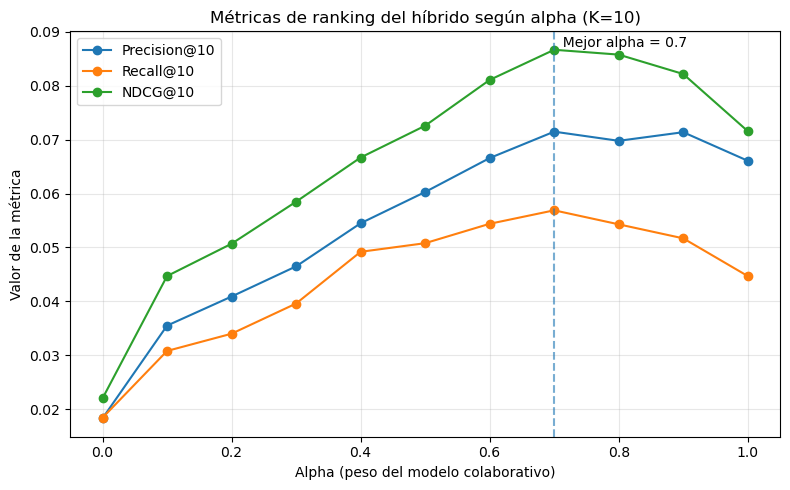

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
for metrica in ['Precision@10', 'Recall@10', 'NDCG@10']:
    ax.plot(df_ranking['alpha'], df_ranking[metrica], marker='o', label=metrica)

ax.axvline(ALPHA_OPTIMO, linestyle='--', alpha=0.6)
ax.text(ALPHA_OPTIMO, df_ranking['NDCG@10'].max(),
        f"  Mejor alpha = {ALPHA_OPTIMO}", verticalalignment='bottom')
ax.set_xlabel('Alpha (peso del modelo colaborativo)')
ax.set_ylabel('Valor de la métrica')
ax.set_title('Métricas de ranking del híbrido según alpha (K=10)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Lectura — ranking

El mejor alpha por NDCG@10 vuelve a ser **0.7** (Precision@10 ≈ 0.072,
Recall@10 ≈ 0.057, NDCG@10 ≈ 0.087), igual que en la búsqueda vieja — pero
ahora el número **significa algo**: está medido con la métrica correcta para
la tarea correcta.

Observaciones:

- La curva tiene la forma esperada: solo contenido (alpha=0) rankea muy mal
  (NDCG ≈ 0.022 — los géneros solos no alcanzan para elegir 10 entre 1600),
  solo colaborativo (alpha=1) es bueno pero no óptimo, y la mezcla 70/30 les
  gana a ambos. **Acá sí el híbrido aporta de verdad**, a diferencia de la
  tarea de predicción de rating.
- Los valores absolutos parecen bajos porque el protocolo es exigente: solo
  contamos como acierto películas que el usuario justo rateó ≥ 4 en el 20%
  de test. Muchas recomendaciones pueden ser buenas y no figurar en el test —
  esto es un piso de la calidad real, no un techo.

### Resumen de la evaluación corregida

| Tarea | Métrica correcta | Mejor configuración | Resultado |
|---|---|---|---|
| Predicción de rating | RMSE (escala 1–5) | SVD k=10 (+contenido w=0.9) | ≈ 0.932 |
| Ranking Top-10 | Precision/Recall/NDCG@10 | híbrido alpha=0.7 | NDCG@10 ≈ 0.087 |

## Guardado del modelo para la app de Streamlit

Guardamos en un `.pkl` todo lo que la interfaz necesita para funcionar
**sin reentrenar nada**:

- el modelo de scikit-surprise ya entrenado,
- la matriz de similitud de contenido,
- el alpha óptimo del análisis de ranking,
- los dataframes de películas y ratings para la interfaz.

Detalle importante: para el modelo que va a producción **reentrenamos con el
100% de los datos** (train + test juntos). El split train/test sirvió para
elegir los hiperparámetros (k y alpha) de forma honesta; una vez elegidos, no
tiene sentido privar al modelo final del 20% de la información — ya no vamos
a volver a medir sobre ese test.

In [29]:
import pickle
import os

os.makedirs('modelo', exist_ok=True)

# modelo definitivo: k óptimo, entrenado con TODOS los datos
trainset_completo = data.build_full_trainset()
modelo_final = SVD(n_factors=K_OPTIMO, random_state=42)
modelo_final.fit(trainset_completo)

objetos_a_guardar = {
    'modelo_svd':   modelo_final,                              # SVD de surprise ya entrenado
    'similitud_df': similitud_df,                              # similitud coseno entre películas
    'movies':       movies,                                    # títulos y géneros
    'ratings':      ratings[['userId', 'movieId', 'rating']],  # historial (para la interfaz)
    'alpha':        ALPHA_OPTIMO,                              # mejor alpha según NDCG@10
    'k':            K_OPTIMO,                                  # mejor k según RMSE de test
}

with open('modelo/modelo_hibrido.pkl', 'wb') as f:
    pickle.dump(objetos_a_guardar, f)

print("Modelo guardado en modelo/modelo_hibrido.pkl ✓")
print(f"k = {K_OPTIMO}, alpha = {ALPHA_OPTIMO}")
print(f"Tamaño: {os.path.getsize('modelo/modelo_hibrido.pkl') / 1e6:.1f} MB")

Modelo guardado en modelo/modelo_hibrido.pkl ✓
k = 10, alpha = 0.7
Tamaño: 28.5 MB


## Prueba final usando el módulo compartido `recomendador.py`

Para que el notebook y la app no tengan cada uno su propia copia de la
lógica (que tarde o temprano se desincroniza), las funciones de scoring
viven en `recomendador.py`, en la raíz del repo. La app las importa, y acá
las probamos con el modelo final recién guardado — exactamente el mismo
código que va a correr en Streamlit.

In [30]:
from recomendador import recomendar_hibrido

# historial del usuario 1 (Series movieId -> rating)
historial_u1 = ratings[ratings['userId'] == 1].set_index('movieId')['rating']

print(f"Recomendaciones híbridas para el usuario 1 "
      f"(k={K_OPTIMO}, alpha={ALPHA_OPTIMO}):\n")
print(recomendar_hibrido(
    modelo_final, similitud_df, movies, historial_u1,
    userId=1, alpha=ALPHA_OPTIMO, n=10
).to_string(index=False))

Recomendaciones híbridas para el usuario 1 (k=10, alpha=0.7):

                                 title  score_final
                Wings of Desire (1987)     0.919903
                     Casablanca (1942)     0.912474
                    Down by Law (1986)     0.882029
             As Good As It Gets (1997)     0.880162
          To Kill a Mockingbird (1962)     0.877643
One Flew Over the Cuckoo's Nest (1975)     0.876993
          Raise the Red Lantern (1991)     0.876362
                 Secrets & Lies (1996)     0.874386
                 Cool Hand Luke (1967)     0.873583
               Schindler's List (1993)     0.873453
